# 📊 Análisis de Tendencias en Google Trends: **Zara · Shein · Temu**
### Módulo: Análisis Avanzado de Datos y Visualización — Práctica Aplicada

**País:** España  |  **Periodo:** 2004–2026  |  **Frecuencia:** mensual  |  **Fuente:** Google Trends (Web Search)

Este notebook realiza el análisis **programático** de la práctica:
1. **A. Análisis descriptivo** — evolución del interés, estacionalidad, comparación entre marcas.
2. **B. Correlaciones** — periodo completo vs. ventana de coexistencia.
3. **C. Descomposición temporal** — tendencia, estacionalidad y residual.
4. **D. Forecast a 6 meses** — con Holt-Winters (suavizado exponencial).

> Escala de Google Trends: valor **relativo 0–100**, donde 100 = máximo interés del periodo analizado.


## 0. Preparación del entorno

In [1]:
# En Google Colab, descomenta para instalar dependencias:
# !pip install pytrends statsmodels matplotlib pandas -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

MARCAS = ["zara", "shein", "temu"]
COLORS = {"zara": "#1f77b4", "shein": "#d62728", "temu": "#2ca02c"}
print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


## 1. Obtención de los datos

Hay **dos formas** de obtener los datos (la práctica acepta ambas):

**Opción A — Programática con `pytrends`** *(recomendada, pero Google puede bloquear la petición con error 429)*:
```python
from pytrends.request import TrendReq
pytrends = TrendReq(hl='es-ES', tz=60)
pytrends.build_payload(['zara','shein','temu'], timeframe='2004-01-01 2026-07-01', geo='ES')
df = pytrends.interest_over_time().drop(columns='isPartial')
```

**Opción B — CSV descargado de Google Trends** *(plan de contingencia, el que usamos aquí)*.
En Colab puedes subirlo con:
```python
from google.colab import files
files.upload()   # selecciona el CSV descargado de Google Trends
```


In [2]:
# --- Carga del CSV descargado de Google Trends ---
import os
CSV_NAME = "google_trends_zara_shein_temu_ES.csv"
# Busca el fichero en varias ubicaciones (repo, carpeta notebook, o cwd en Colab)
candidatos = [f"data/{CSV_NAME}", f"../data/{CSV_NAME}", CSV_NAME, f"/content/{CSV_NAME}"]
ruta = next((p for p in candidatos if os.path.exists(p)), None)
assert ruta, f"No encuentro el CSV. En Colab, súbelo con files.upload(). Buscado en: {candidatos}"
print("Cargando datos desde:", ruta)

df = pd.read_csv(ruta, parse_dates=["Time"])
df = df.rename(columns={"Time": "fecha"}).set_index("fecha").sort_index()
df.index.freq = "MS"  # frecuencia mensual (Month Start)

print("Dimensiones:", df.shape)
print("Rango temporal:", df.index.min().date(), "->", df.index.max().date())
df.head()

Cargando datos desde: ../data/google_trends_zara_shein_temu_ES.csv
Dimensiones: (270, 3)
Rango temporal: 2004-01-01 -> 2026-06-01


,zara,shein,temu
fecha,,,
2004-01-01,8,0,0
2004-02-01,8,0,0
2004-03-01,7,0,0
2004-04-01,9,0,0
2004-05-01,8,0,0


### 1.1. Validación de calidad de los datos
Comprobamos que la serie está limpia antes de analizarla.

In [3]:
print("Valores nulos:      ", df.isna().sum().sum())
print("Fechas duplicadas:  ", df.index.duplicated().sum())
rango = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Meses esperados:    ", len(rango), "| presentes:", len(df),
      "| huecos:", len(set(rango) - set(df.index)))
print("Valores en [0,100]: ", df[MARCAS].apply(lambda s: s.between(0,100).all()).to_dict())

Valores nulos:       0
Fechas duplicadas:   0
Meses esperados:     270 | presentes: 270 | huecos: 0
Valores en [0,100]:  {'zara': True, 'shein': True, 'temu': True}


## A. Análisis descriptivo

Estudiamos cómo ha evolucionado el interés de cada marca desde 2004.

In [4]:
df.describe().round(2)

,zara,shein,temu
count,270.00,270.00,270.00
mean,41.97,7.69,1.64
std,23.48,11.39,4.27
min,6.00,0.00,0.00
25%,12.00,0.00,0.00
50%,47.50,0.00,0.00
75%,57.75,15.00,0.00
max,100.00,43.00,19.00


In [5]:
# Primer mes con interés > 0 (aparición de cada marca)
aparicion = {c: df.loc[df[c] > 0].index.min() for c in MARCAS}
for c, f in aparicion.items():
    print(f"{c:6s}: aparece en {f.date()}")

zara  : aparece en 2004-01-01
shein : aparece en 2015-11-01
temu  : aparece en 2023-05-01


In [6]:
# Resumen comparativo: media, pico y crecimiento acumulado
resumen = []
for c in MARCAS:
    serie = df[c]; activo = serie[serie > 0]
    ini, fin = activo.head(12).mean(), activo.tail(12).mean()
    crec = (fin - ini) / ini * 100 if ini > 0 else np.nan
    resumen.append({"marca": c, "media_global": round(serie.mean(),1),
                    "media_ult_12m": round(serie.tail(12).mean(),1),
                    "pico_max": int(serie.max()), "mes_pico": serie.idxmax().strftime("%Y-%m"),
                    "crecimiento_%": round(crec,1)})
resumen = pd.DataFrame(resumen); resumen

,marca,media_global,media_ult_12m,pico_max,mes_pico,crecimiento_%
0,zara,42.0,48.1,100,2017-11,460.2
1,shein,7.7,21.0,43,2022-06,1838.5
2,temu,1.6,15.2,19,2025-11,104.5


### A.1. Evolución del interés (2004–2026)

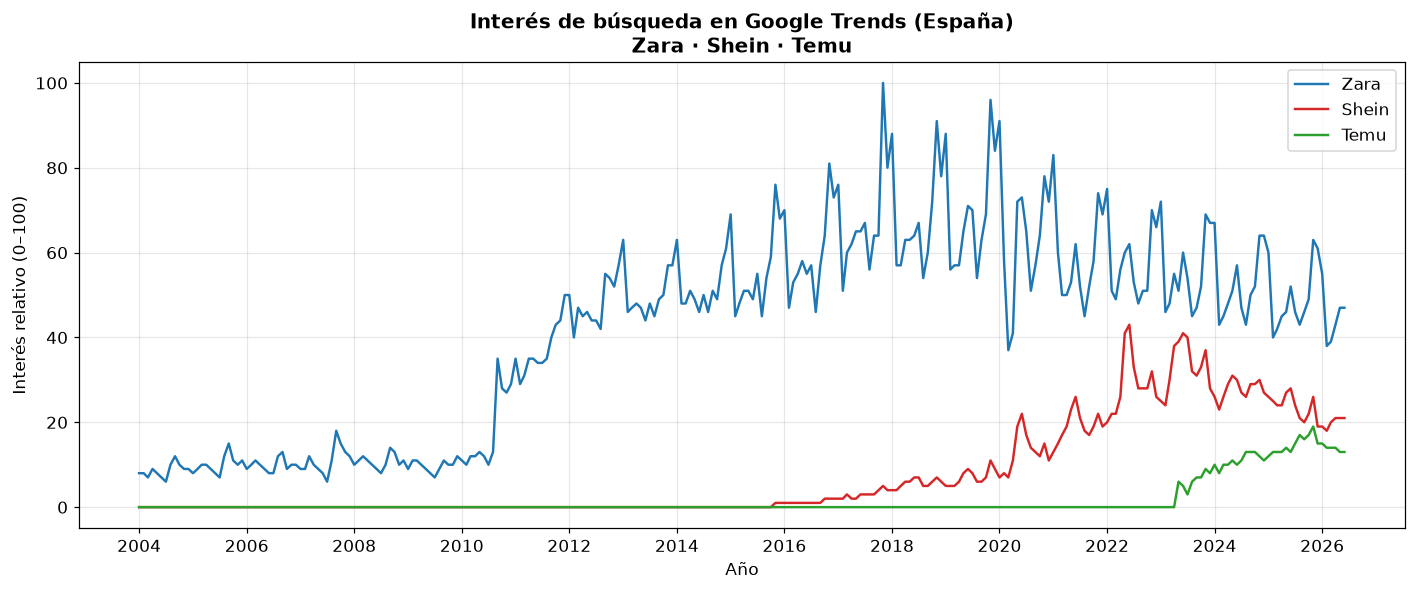

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5))
for c in MARCAS:
    ax.plot(df.index, df[c], label=c.capitalize(), color=COLORS[c], lw=1.6)
ax.set_title("Interés de búsqueda en Google Trends (España)\nZara · Shein · Temu", fontweight="bold")
ax.set_ylabel("Interés relativo (0–100)"); ax.set_xlabel("Año"); ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

### A.2. Estacionalidad: patrón medio por mes (Zara)

Buscamos si los picos coinciden con **rebajas (enero)**, **Black Friday (noviembre)** o **Navidad (diciembre)**.

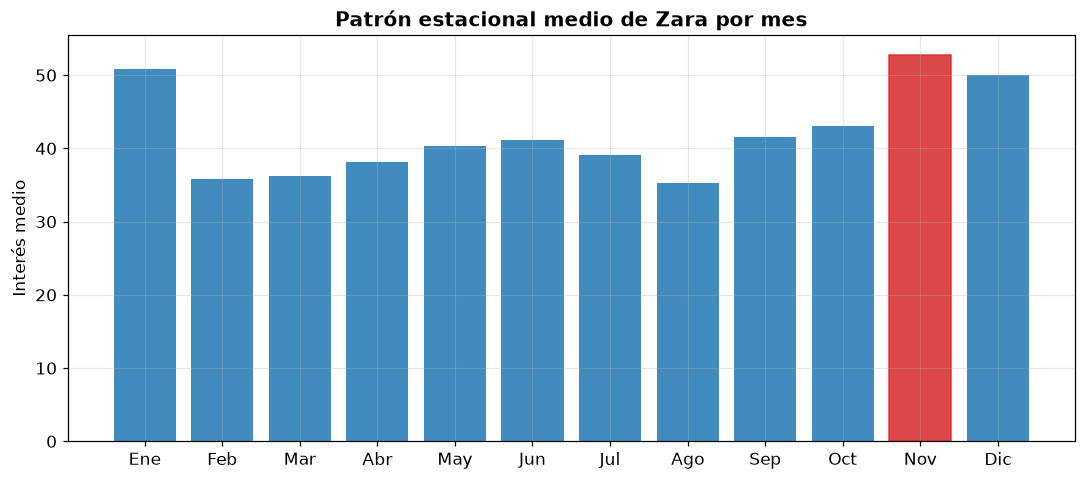

In [8]:
df_m = df.copy(); df_m["mes"] = df_m.index.month
estacional = df_m.groupby("mes")["zara"].mean()
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(meses, estacional.values, color=COLORS["zara"], alpha=0.85)
for i,b in enumerate(bars):
    if estacional.values[i] >= estacional.max()*0.97: b.set_color("#d62728")
ax.set_title("Patrón estacional medio de Zara por mes", fontweight="bold"); ax.set_ylabel("Interés medio")
plt.tight_layout(); plt.show()

## B. Correlaciones

⚠️ **Nota metodológica clave:** correlacionar todo el periodo 2004–2026 está **sesgado**, porque
Shein y Temu valen 0 durante años. La correlación con sentido se calcula en la **ventana donde
coexisten las tres marcas** (desde que aparece Temu, may-2023).

In [9]:
corr_full = df[MARCAS].corr()
print("Periodo completo 2004–2026 (SESGADO por los ceros):")
corr_full.round(3)

Periodo completo 2004–2026 (SESGADO por los ceros):


,zara,shein,temu
zara,1.000,0.418,0.140
shein,0.418,1.000,0.602
temu,0.140,0.602,1.000


In [10]:
inicio_coex = aparicion["temu"]
df_coex = df.loc[inicio_coex:]
corr_coex = df_coex[MARCAS].corr()
print(f"Ventana de coexistencia (desde {inicio_coex.date()}):")
corr_coex.round(3)

Ventana de coexistencia (desde 2023-05-01):


,zara,shein,temu
zara,1.000,0.404,-0.209
shein,0.404,1.000,-0.781
temu,-0.209,-0.781,1.000


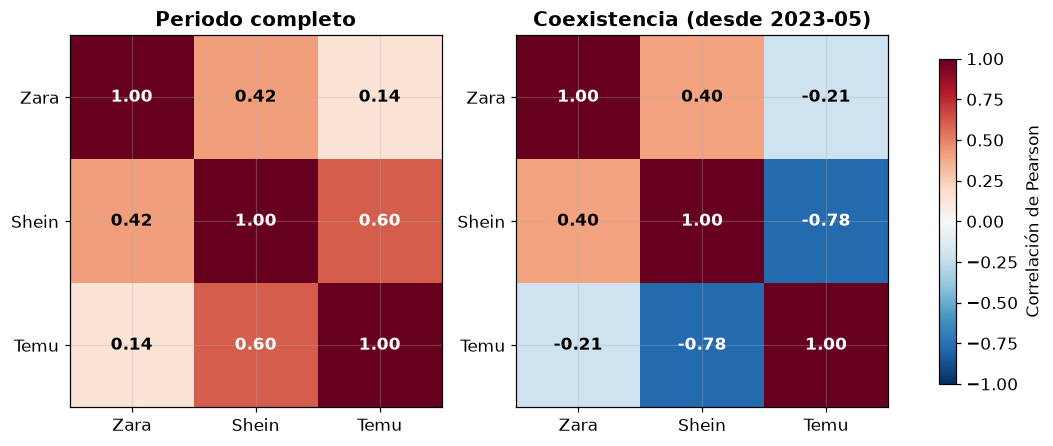

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax,(titulo,cm) in zip(axes,[("Periodo completo",corr_full),
                                 (f"Coexistencia (desde {inicio_coex.strftime('%Y-%m')})",corr_coex)]):
    im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels([m.capitalize() for m in MARCAS])
    ax.set_yticks(range(3)); ax.set_yticklabels([m.capitalize() for m in MARCAS])
    for i in range(3):
        for j in range(3):
            ax.text(j,i,f"{cm.iloc[i,j]:.2f}",ha="center",va="center",
                    color="white" if abs(cm.iloc[i,j])>0.5 else "black", fontweight="bold")
    ax.set_title(titulo, fontweight="bold")
fig.colorbar(im, ax=axes, shrink=0.8, label="Correlación de Pearson"); plt.show()

**Interpretación de correlaciones:**
- **Temu ↔ Shein: fuertemente negativa** en la ventana de coexistencia → cuando sube Temu, baja Shein (sustitución competitiva directa: mismo perfil de consumidor de bajo coste).
- **Zara ↔ Shein: positiva débil/moderada** → comparten estacionalidad de consumo pero no compiten frontalmente.
- **Zara ↔ Temu: prácticamente nula o ligeramente negativa** → segmentos distintos.


## C. Descomposición temporal (obligatorio)

Separamos cada serie en **tendencia + estacionalidad + residual** (modelo aditivo, periodo=12 meses).

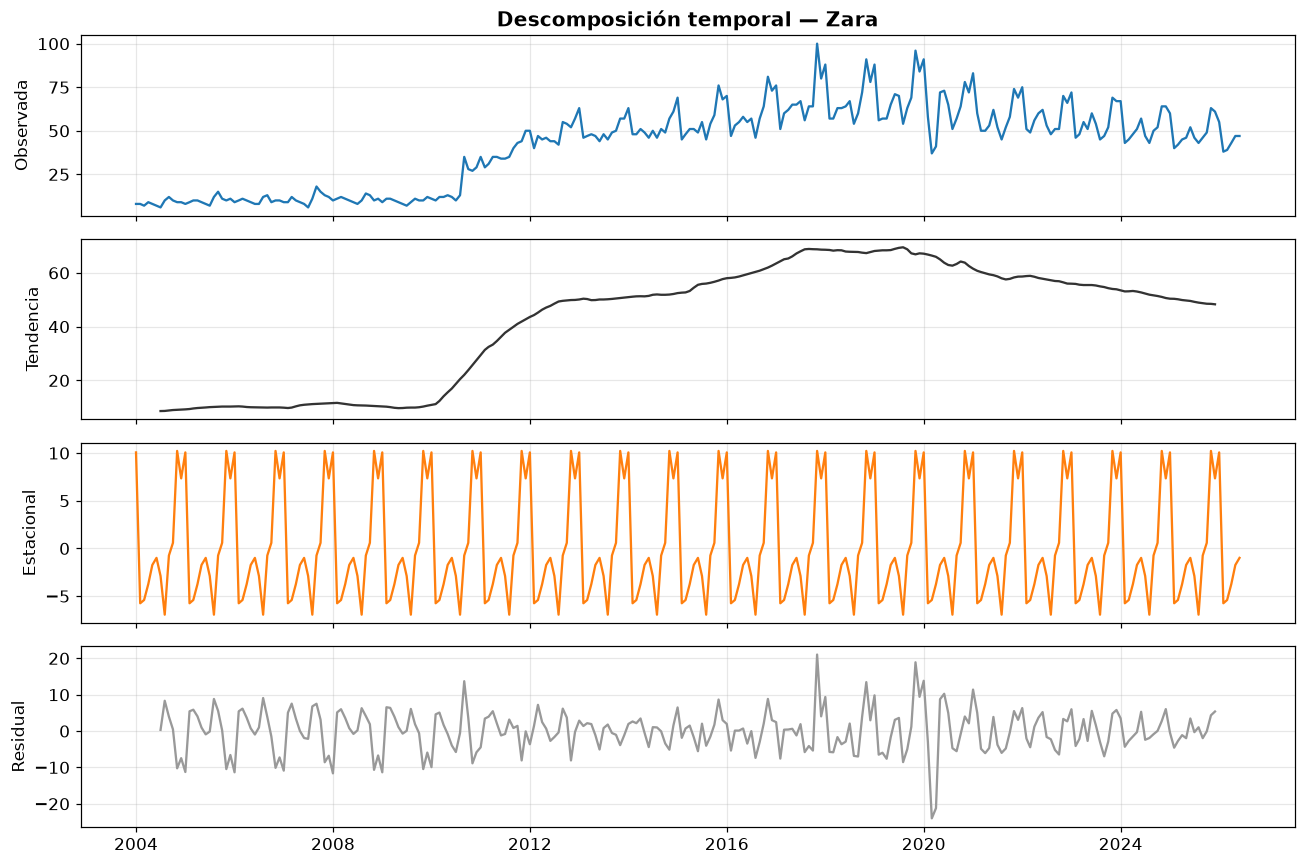

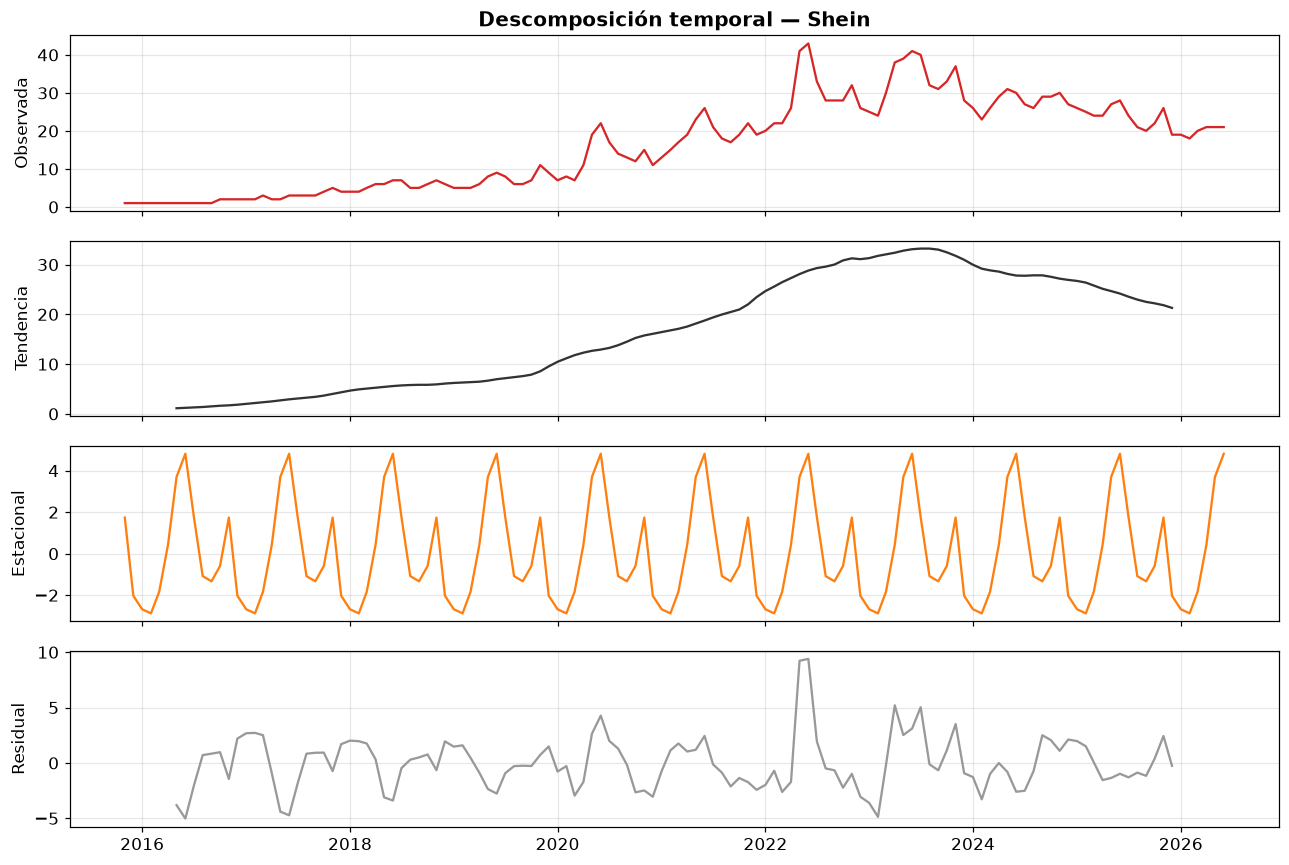

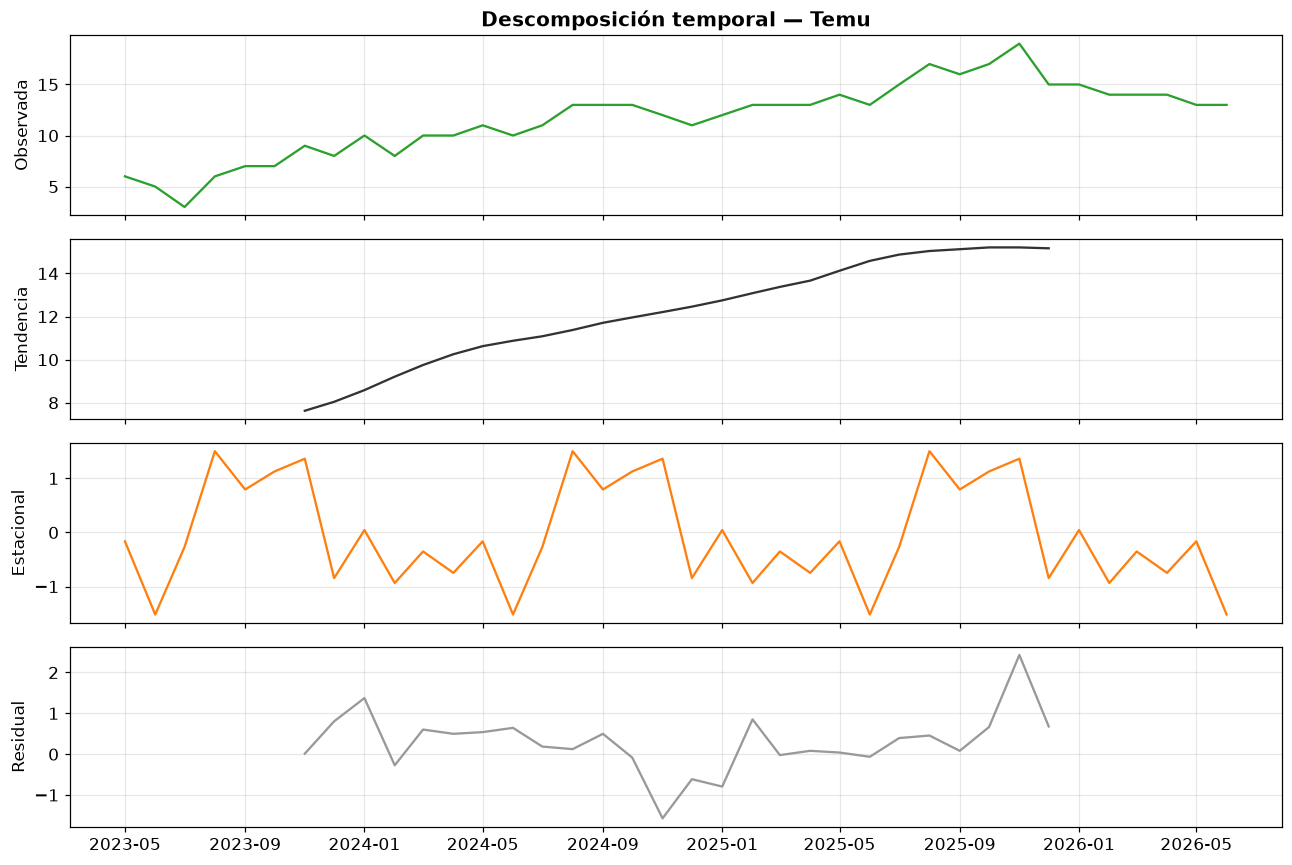

,tendencia_%,estacional_%,residual_%
zara,87.0,6.0,5.9
shein,89.6,4.4,4.3
temu,44.1,7.2,4.2


In [12]:
var_explicada = {}
for c in MARCAS:
    serie = df.loc[aparicion[c]:, c].astype(float)
    if len(serie) < 24: continue
    res = seasonal_decompose(serie, model="additive", period=12)
    fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    ax[0].plot(serie.index, serie, color=COLORS[c]); ax[0].set_ylabel("Observada")
    ax[1].plot(res.trend.index, res.trend, color="#333"); ax[1].set_ylabel("Tendencia")
    ax[2].plot(res.seasonal.index, res.seasonal, color="#ff7f0e"); ax[2].set_ylabel("Estacional")
    ax[3].plot(res.resid.index, res.resid, color="#999"); ax[3].set_ylabel("Residual")
    ax[0].set_title(f"Descomposición temporal — {c.capitalize()}", fontweight="bold")
    plt.tight_layout(); plt.show()
    tv = serie.var()
    var_explicada[c] = {"tendencia_%": round(res.trend.dropna().var()/tv*100,1),
                        "estacional_%": round(res.seasonal.var()/tv*100,1),
                        "residual_%": round(res.resid.dropna().var()/tv*100,1)}
pd.DataFrame(var_explicada).T

**Interpretación:** en las tres marcas la **tendencia** es el componente que más variabilidad explica.
La **estacionalidad** es estable y recurrente (picos de fin de año). El **residual** es pequeño, lo que indica
series bien estructuradas y predecibles.

## D. Forecast a 6 meses

Usamos **Holt-Winters** (suavizado exponencial con tendencia y estacionalidad aditivas), adecuado para
series mensuales con patrón estacional.

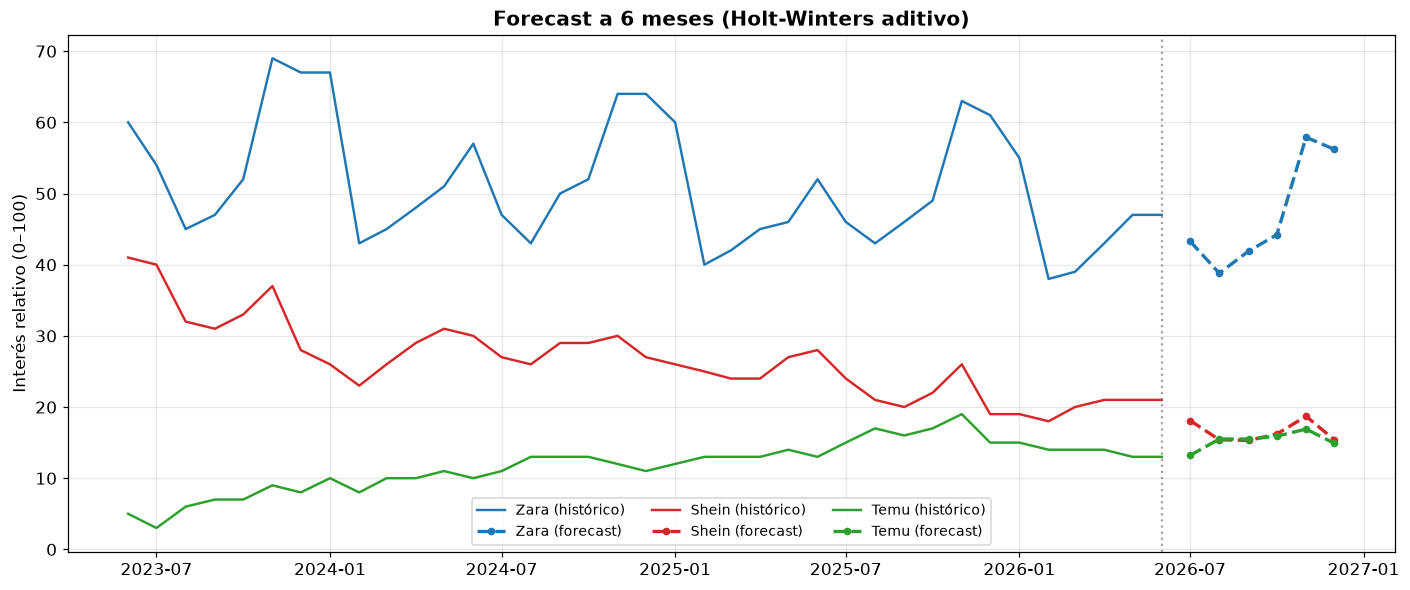

In [13]:
H = 6
forecasts = {}
fig, ax = plt.subplots(figsize=(13, 5.5))
for c in MARCAS:
    serie = df.loc[aparicion[c]:, c].astype(float)
    ajuste = ExponentialSmoothing(serie, trend="add", seasonal="add", seasonal_periods=12).fit()
    pred = ajuste.forecast(H).clip(lower=0).round(1); forecasts[c] = pred
    hist = serie.loc[serie.index.max()-pd.DateOffset(years=3):]
    ax.plot(hist.index, hist, color=COLORS[c], lw=1.6, label=f"{c.capitalize()} (histórico)")
    ax.plot(pred.index, pred, color=COLORS[c], lw=2.2, ls="--", marker="o", ms=4, label=f"{c.capitalize()} (forecast)")
ax.axvline(df.index.max(), color="gray", ls=":", alpha=0.7)
ax.set_title("Forecast a 6 meses (Holt-Winters aditivo)", fontweight="bold")
ax.set_ylabel("Interés relativo (0–100)"); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

### D.1. Tabla de predicción (6 meses)

In [14]:
tabla_forecast = pd.DataFrame(forecasts); tabla_forecast.index.name = "fecha"
_out = "resultados" if os.path.isdir("resultados") else ("../resultados" if os.path.isdir("../resultados") else ".")
tabla_forecast.to_csv(f"{_out}/forecast_6meses.csv")   # exporta CSV
tabla_forecast

,zara,shein,temu
fecha,,,
2026-07-01,43.3,18.1,13.2
2026-08-01,38.8,15.4,15.5
2026-09-01,41.9,15.3,15.5
2026-10-01,44.2,16.2,15.9
2026-11-01,57.9,18.7,16.9
2026-12-01,56.2,15.4,14.9


## Conclusiones

- **Zara** domina el interés en toda la serie (media ≈ 42 vs. 7.7 de Shein y 1.6 de Temu), aunque su pico histórico fue en **noviembre de 2017**. Es una marca **madura** con fuerte estacionalidad.
- **Shein** despega con la pandemia (2020) y alcanza su máximo en **2022**; desde entonces se estabiliza / cede ligeramente.
- **Temu** entra muy tarde (**may-2023**) pero crece de forma sostenida, alcanzando a Shein en interés hacia 2025–2026.
- **Correlación más fuerte:** Temu ↔ Shein (negativa) en la ventana de coexistencia → **sustitución competitiva directa**.
- **Estacionalidad** clara y común: picos en **noviembre (Black Friday)** y **enero (rebajas)**, valles en **febrero/agosto**.
- El **forecast** proyecta la continuidad de estos patrones: repunte estacional de fin de año y Temu consolidándose.

> **Nota sobre el forecast:** Holt-Winters es una estimación estadística basada en tendencia y estacionalidad
> históricas; no incorpora factores externos (campañas, regulación, etc.). El objetivo de la práctica es
> aprender la metodología, no la precisión exacta de la predicción.
